# SDE 蒙特卡洛分布

这个 notebook 是 pyna 的一个实用 SDE 案例研究。它用 pyna 的 SDE 类描述模型边界和单路径几何，再用向量化的 NumPy 样本集合估计分布。

这个 notebook 已经有意在本地预执行。保存的输出会由 GitHub Pages 上的 Sphinx/nbsphinx 渲染，因此文档流程不需要在 CI 中反复消耗 CPU 做蒙特卡洛采样。


In [1]:
%matplotlib inline
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')

import numpy as np
import matplotlib.pyplot as plt

from pyna.dynamics import BrownianMotion, GeometricBrownianMotion, ItoSDE

plt.rcParams.update({
    "figure.figsize": (10, 4),
    "axes.grid": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

rng = np.random.default_rng(20260701)
print("rng seed = 20260701")

rng seed = 20260701


## 布朗运动：终端分布

单条布朗运动样本路径是一个 `Trajectory`。大量样本集合可以估计概率分布。对布朗运动而言，终端分布有解析形式，因此它很适合作为蒙特卡洛代码的回归检查。


paths = 60,000, steps = 600, T = 2.0
mean: empirical 0.29974, analytic 0.30000, abs error 0.00026
var : empirical 2.00725, analytic 2.00000, abs error 0.00725


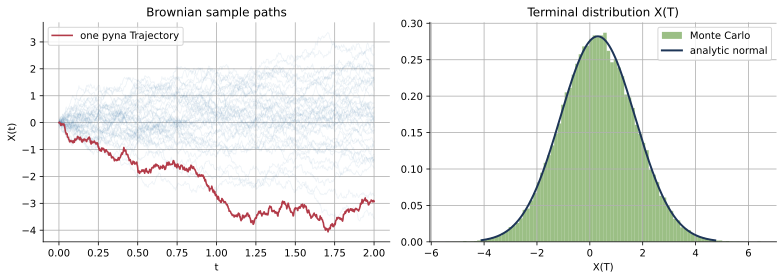

In [2]:
bm = BrownianMotion(dim=1, diffusion=1.0, drift=[0.15])
single_path = bm.euler_maruyama([0.0], (0.0, 2.0), dt=0.002, rng=7)

n_paths = 60_000
n_steps = 600
T = 2.0
dt = T / n_steps

increments = np.sqrt(dt) * rng.normal(size=(n_paths, n_steps))
terminal = bm.drift_vector[0] * T + increments.sum(axis=1)

times = np.linspace(0.0, T, n_steps + 1)
fan_count = 40
fan_paths = np.empty((fan_count, n_steps + 1))
fan_paths[:, 0] = 0.0
fan_paths[:, 1:] = bm.drift_vector[0] * times[1:] + np.cumsum(increments[:fan_count], axis=1)

analytic_mean = bm.mean([0.0], T)[0]
analytic_var = bm.variance(T)[0]
empirical_mean = float(np.mean(terminal))
empirical_var = float(np.var(terminal, ddof=1))

x_grid = np.linspace(np.quantile(terminal, 0.001), np.quantile(terminal, 0.999), 400)
pdf = np.exp(-0.5 * (x_grid - analytic_mean) ** 2 / analytic_var) / np.sqrt(2 * np.pi * analytic_var)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(times, fan_paths.T, color="#2f6f9f", alpha=0.08, linewidth=0.8)
axes[0].plot(single_path.t, single_path.y[:, 0], color="#b23a48", linewidth=1.6, label="one pyna Trajectory")
axes[0].set_title("Brownian sample paths")
axes[0].set_xlabel("t")
axes[0].set_ylabel("X(t)")
axes[0].legend(loc="upper left")

axes[1].hist(terminal, bins=90, density=True, color="#7aa95c", alpha=0.75, label="Monte Carlo")
axes[1].plot(x_grid, pdf, color="#1d3557", linewidth=2.0, label="analytic normal")
axes[1].set_title("Terminal distribution X(T)")
axes[1].set_xlabel("X(T)")
axes[1].legend()
plt.tight_layout()

print(f"paths = {n_paths:,}, steps = {n_steps}, T = {T}")
print(f"mean: empirical {empirical_mean:.5f}, analytic {analytic_mean:.5f}, abs error {abs(empirical_mean - analytic_mean):.5f}")
print(f"var : empirical {empirical_var:.5f}, analytic {analytic_var:.5f}, abs error {abs(empirical_var - analytic_var):.5f}")

## Ornstein-Uhlenbeck：趋近稳态分布

OU 过程是讲解均值回复的紧凑教学模型。它也演示了如何用用户自定义漂移项和扩散项构造 `ItoSDE`。蒙特卡洛样本集合用于检查有限时间正态分布和稳态方差。


paths = 80,000, steps = 1200, T = 3.0
mean: empirical 1.48901, analytic 1.48871, abs error 0.00030
var : empirical 0.03427, finite-time 0.03403, stationary 0.03403


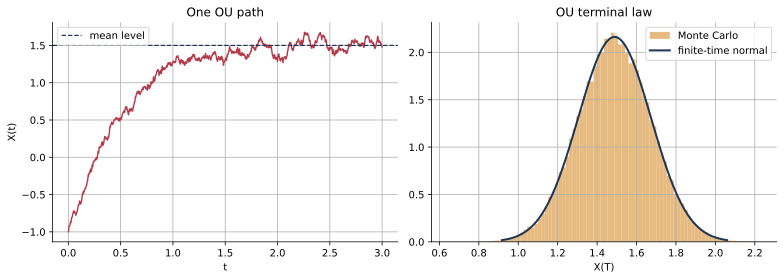

In [3]:
theta = 1.8
mean_level = 1.5
sigma = 0.35
x0 = -1.0
T = 3.0
n_steps = 1200
dt = T / n_steps
n_paths = 80_000

ou = ItoSDE(
    drift=lambda x, t: theta * (mean_level - x),
    diffusion=lambda x, t: np.array([sigma]),
    dim=1,
    brownian_dim=1,
    coordinate_names=("x",),
    label="Ornstein-Uhlenbeck",
)
ou_path = ou.euler_maruyama([x0], (0.0, T), dt=dt, rng=11)

x = np.full(n_paths, x0, dtype=float)
sqrt_dt_sigma = sigma * np.sqrt(dt)
for _ in range(n_steps):
    x += theta * (mean_level - x) * dt + sqrt_dt_sigma * rng.normal(size=n_paths)

analytic_mean = mean_level + (x0 - mean_level) * np.exp(-theta * T)
analytic_var = sigma**2 / (2 * theta) * (1 - np.exp(-2 * theta * T))
stationary_var = sigma**2 / (2 * theta)
empirical_mean = float(np.mean(x))
empirical_var = float(np.var(x, ddof=1))

grid = np.linspace(np.quantile(x, 0.001), np.quantile(x, 0.999), 400)
pdf = np.exp(-0.5 * (grid - analytic_mean) ** 2 / analytic_var) / np.sqrt(2 * np.pi * analytic_var)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(ou_path.t, ou_path.y[:, 0], color="#b23a48", linewidth=1.4)
axes[0].axhline(mean_level, color="#1d3557", linestyle="--", linewidth=1.2, label="mean level")
axes[0].set_title("One OU path")
axes[0].set_xlabel("t")
axes[0].set_ylabel("X(t)")
axes[0].legend()

axes[1].hist(x, bins=90, density=True, color="#e0a458", alpha=0.76, label="Monte Carlo")
axes[1].plot(grid, pdf, color="#1d3557", linewidth=2.0, label="finite-time normal")
axes[1].set_title("OU terminal law")
axes[1].set_xlabel("X(T)")
axes[1].legend()
plt.tight_layout()

print(f"paths = {n_paths:,}, steps = {n_steps}, T = {T}")
print(f"mean: empirical {empirical_mean:.5f}, analytic {analytic_mean:.5f}, abs error {abs(empirical_mean - analytic_mean):.5f}")
print(f"var : empirical {empirical_var:.5f}, finite-time {analytic_var:.5f}, stationary {stationary_var:.5f}")

## 几何布朗运动：类股票资产的长期行为

几何布朗运动是乘性噪声的风格化教学模型。它有助于解释对数增长，但它不是交易建议，也不是现实市场模拟器。


paths = 250,000, horizon = 10 years
expected log growth = 0.0600 per year
mean terminal: empirical 222.55, analytic 222.55
P[S(T) < S0] = 0.171
terminal quantiles 5/25/50/75/95% = [ 64.56 119.13 182.27 279.15 516.16]


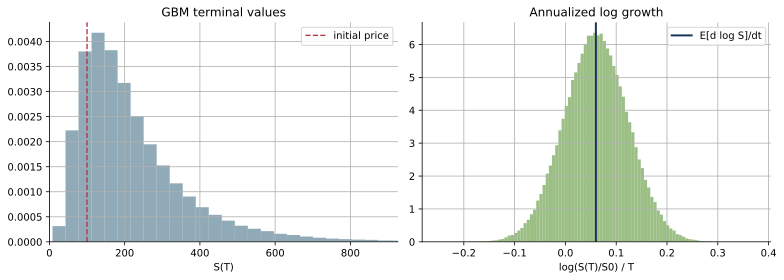

In [4]:
gbm = GeometricBrownianMotion(mu=[0.08], sigma=[0.20])
S0 = 100.0
T = 10.0
n_paths = 250_000

z = rng.normal(size=n_paths)
log_growth_rate = gbm.expected_log_growth()[0]
log_terminal = np.log(S0) + log_growth_rate * T + gbm.sigma[0] * np.sqrt(T) * z
terminal = np.exp(log_terminal)
annualized_log_returns = np.log(terminal / S0) / T

analytic_mean = gbm.mean([S0], T)[0]
empirical_mean = float(np.mean(terminal))
prob_loss = float(np.mean(terminal < S0))
quantiles = np.quantile(terminal, [0.05, 0.25, 0.50, 0.75, 0.95])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(terminal, bins=120, density=True, color="#6b8e9f", alpha=0.75)
axes[0].axvline(S0, color="#b23a48", linestyle="--", linewidth=1.4, label="initial price")
axes[0].set_title("GBM terminal values")
axes[0].set_xlabel("S(T)")
axes[0].set_xlim(0, np.quantile(terminal, 0.995))
axes[0].legend()

axes[1].hist(annualized_log_returns, bins=100, density=True, color="#7aa95c", alpha=0.75)
axes[1].axvline(log_growth_rate, color="#1d3557", linewidth=2.0, label="E[d log S]/dt")
axes[1].set_title("Annualized log growth")
axes[1].set_xlabel("log(S(T)/S0) / T")
axes[1].legend()
plt.tight_layout()

print(f"paths = {n_paths:,}, horizon = {T:g} years")
print(f"expected log growth = {log_growth_rate:.4f} per year")
print(f"mean terminal: empirical {empirical_mean:.2f}, analytic {analytic_mean:.2f}")
print(f"P[S(T) < S0] = {prob_loss:.3f}")
print("terminal quantiles 5/25/50/75/95% =", np.round(quantiles, 2))

## 本节验证的内容

- pyna SDE 模型可以生成可复现的单路径 `Trajectory` 对象。
- 布朗运动和 OU 的经验终端分布在蒙特卡洛误差范围内匹配解析均值与方差。
- GBM 展示算术平均增长与长期对数增长之间的差异。

在生产级蒙特卡洛中，建议把模型边界保留在 pyna 内，并把样本集合内核迁移到向量化、并行化或加速器后端实现。不要把一个样本集合提升为 `Cycle`、`Tube` 或 `IslandChain`，除非对应的几何声明是明确的，并且已经经过数值验证。
